In [14]:
import pandas as pd 
df = pd.read_csv('../data/raw/marketing_campaign_dataset.csv')
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [15]:
df.shape

(200000, 16)

In [16]:
df.columns

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience',
       'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost',
       'ROI', 'Location', 'Language', 'Clicks', 'Impressions',
       'Engagement_Score', 'Customer_Segment', 'Date'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [18]:
df.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [19]:
df.duplicated().sum()

0

In [20]:
df.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


In [21]:
df['Date']=pd.to_datetime(df['Date'])

In [22]:
print("Start Date:",df['Date'].min())
print("End Date:",df['Date'].max())

Start Date: 2021-01-01 00:00:00
End Date: 2021-12-31 00:00:00


In [23]:
df['Channel_Used'].value_counts()

Channel_Used
Email         33599
Google Ads    33438
YouTube       33392
Instagram     33392
Website       33360
Facebook      32819
Name: count, dtype: int64

In [24]:
df['Campaign_Type'].value_counts()

Campaign_Type
Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: count, dtype: int64

In [25]:
df['Customer_Segment'].value_counts()

Customer_Segment
Foodies                40208
Tech Enthusiasts       40151
Outdoor Adventurers    40011
Health & Wellness      39888
Fashionistas           39742
Name: count, dtype: int64

In [26]:
df.groupby('Channel_Used')['ROI'].mean().sort_values(ascending=False)

Channel_Used
Facebook      5.018699
Website       5.014167
Google Ads    5.003141
Email         4.996487
YouTube       4.993754
Instagram     4.988706
Name: ROI, dtype: float64

In [27]:
df.groupby('Channel_Used')['Conversion_Rate'].mean().sort_values(ascending=False)

Channel_Used
Email         0.080282
Google Ads    0.080183
Website       0.080183
Facebook      0.079992
YouTube       0.079889
Instagram     0.079886
Name: Conversion_Rate, dtype: float64

Observations:
1. The dataset covers marketing campaigns from January 2021 to December 2021.
2. Email is the most frequently used marketing channel, while Facebook is the least used.
3. Campaign types and customer segments are evenly distributed across the dataset.
4. Facebook generated the highest average ROI among all channels.
5. Email achieved the highest average conversion rate.
6. Instagram showed the lowest ROI and conversion rate among the analyzed channels.

Text(0.5, 1.0, 'Average ROI by Channel')

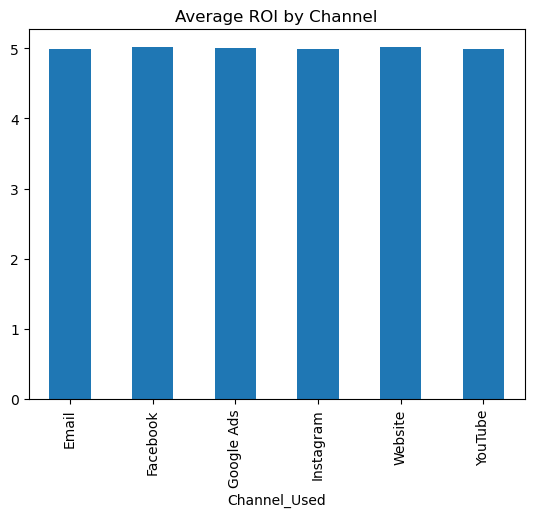

In [28]:
import matplotlib.pyplot as plt
df.groupby('Channel_Used')['ROI'].mean().plot(kind='bar')
plt.title('Average ROI by Channel')

Observation:
1. The average ROI across all marketing channels is approximately 5.
2. Facebook generates the highest ROI among all channels.
3. Instagram generates the lowest ROI.
4. The ROI differences between channels are small, indicating balanced performance.
5. Overall, all marketing channels contribute positively to campaign returns.

In [29]:
df.groupby('Campaign_Type')['ROI'].mean().sort_values(ascending=False)


Campaign_Type
Influencer      5.011068
Search          5.008357
Display         5.006551
Email           4.994295
Social Media    4.991784
Name: ROI, dtype: float64

In [30]:
df.groupby('Campaign_Type')['Conversion_Rate'].mean().sort_values(ascending=False)

Campaign_Type
Influencer      0.080315
Social Media    0.080135
Display         0.080089
Search          0.080021
Email           0.079788
Name: Conversion_Rate, dtype: float64

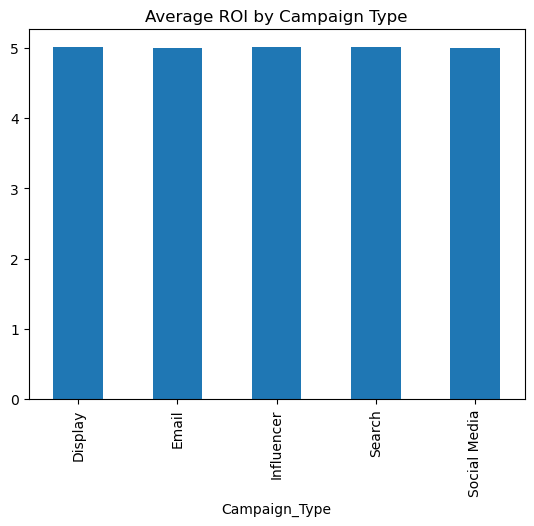

In [31]:
df.groupby('Campaign_Type')['ROI'].mean().plot(kind='bar')
plt.title('Average ROI by Campaign Type')
plt.show()

In [32]:
df.groupby('Customer_Segment')['ROI'].mean().sort_values(ascending=False)

Customer_Segment
Foodies                5.004376
Tech Enthusiasts       5.004234
Health & Wellness      5.003202
Fashionistas           5.000962
Outdoor Adventurers    4.999393
Name: ROI, dtype: float64

In [33]:
df.groupby('Customer_Segment')['Conversion_Rate'].mean().sort_values(ascending=False)

Customer_Segment
Foodies                0.080257
Outdoor Adventurers    0.080180
Tech Enthusiasts       0.080168
Health & Wellness      0.079945
Fashionistas           0.079794
Name: Conversion_Rate, dtype: float64

In [ ]:
df.groupby('Customer_Segment')['ROI'].mean().plot(kind='bar')
plt.title('Average ROI by Customer Segment')
plt.ylabel('ROI')
plt.show()